## IMPORT

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
import math
import lightgbm as lgb
import seaborn as sns
import joblib as jbl
from catboost import CatBoostClassifier
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import classification_report, confusion_matrix

 ## PRE PROCESSING

In [2]:
df = pd.read_parquet("US_accidents_dataset.parquet")
df.drop(columns=["Turning_Loop", "End_Lat", "End_Lng", "Airport_Code"], inplace=True)

df['Start_Time'] = pd.to_datetime(df['Start_Time'], format='mixed')
df['End_Time']   = pd.to_datetime(df['End_Time'],   format='mixed')
df['duration_min'] = (df['End_Time'] - df['Start_Time']).dt.total_seconds() / 60
df['hour']  = df['Start_Time'].dt.hour
df['month'] = df['Start_Time'].dt.month

def is_us_holiday(dt):
    m, d = dt.month, dt.day
    if (m == 12 and d >= 24) or (m == 1 and d <= 2): return 1
    if m == 11 and d >= 22:      return 1
    if m == 7  and d == 4:       return 1
    if m == 5  and d >= 25:      return 1
    if m == 9  and d <= 7:       return 1
    if m == 10 and d == 31:      return 1
    if m == 2  and 7 <= d <= 10: return 1
    return 0

df['is_holiday_period'] = df['Start_Time'].apply(is_us_holiday)
df.drop(columns=['Start_Time', 'End_Time', 'Weather_Timestamp'], inplace=True)
df.drop(columns=['Wind_Chill(F)', 'Country'], inplace=True)

def time_of_day(h):
    if 6  <= h < 9:  return 0  # morning_rush
    if 9  <= h < 16: return 1  # daytime
    if 16 <= h < 19: return 2  # evening_rush
    if 19 <= h < 23: return 3  # evening
    return 4                   # night

df['time_of_day'] = df['hour'].apply(time_of_day)

# Encoding ciclico mese
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
df.drop(columns=['hour', 'month'], inplace=True)

def group_weather(w):
    if pd.isna(w): return 'Unknown'
    w = str(w).lower()
    if any(x in w for x in ['thunder', 't-storm', 'thunderstorm', 'tornado', 'funnel']): return 'Storm'
    if any(x in w for x in ['snow', 'blizzard', 'wintry', 'sleet', 'ice pellet', 'snow grain', 'freezing', 'hail']): return 'Snow_Ice'
    if any(x in w for x in ['heavy rain', 'rain shower', 'rain', 'drizzle', 'shower']): return 'Rain'
    if any(x in w for x in ['fog', 'mist', 'haze']):                                    return 'Fog_Low_Visibility'
    if any(x in w for x in ['smoke', 'dust', 'sand', 'ash', 'squall']):                 return 'Dust_Smoke'
    if any(x in w for x in ['cloud', 'overcast', 'scattered', 'mostly', 'partly']):     return 'Cloudy'
    if any(x in w for x in ['clear', 'fair', 'sunny']):                                 return 'Clear'
    return 'Other'

def weather_intensity(w):
    if pd.isna(w): return np.nan
    w = str(w).lower()
    if any(x in w for x in ['heavy', 'severe', 'tornado', 'funnel', 'blizzard', 'duststorm']): return 3
    if any(x in w for x in ['moderate', 'thunder', 't-storm', 'squall', 'wintry mix']):         return 2
    if any(x in w for x in ['light', 'drizzle', 'mist', 'shallow', 'partial', 'patches']):      return 1
    return 0

df['Weather_Group']     = df['Weather_Condition'].apply(group_weather)
df['Weather_Intensity'] = df['Weather_Condition'].apply(weather_intensity)
df.drop(columns=['Weather_Condition'], inplace=True)

def classify_street(name):
    if pd.isna(name): return 'Unknown'
    name_upper = str(name).upper().strip()
    name_clean = re.sub(r'\s+(N|S|E|W|NE|NW|SE|SW)$', '', name_upper).strip()
    if re.match(r'^I-\d+', name_clean):          return 'Interstate'
    if re.match(r'^US-\d+', name_clean):         return 'US_Route'
    if re.match(r'^[A-Z]{2}-\d+', name_clean):  return 'State_Route'
    if any(x in name_clean for x in ['FWY', 'FREEWAY', 'EXPRESSWAY', 'EXPY', 'TPKE', 'TURNPIKE', 'PIKE']): return 'Freeway_Expressway'
    if any(x in name_clean for x in ['HWY', 'HIGHWAY']):    return 'Highway'
    if any(x in name_clean for x in ['PKWY', 'PARKWAY']):   return 'Parkway'
    if any(x in name_clean for x in ['BLVD', 'BOULEVARD']): return 'Boulevard'
    if any(x in name_clean for x in [' AVE', 'AVENUE']):    return 'Avenue'
    if any(x in name_clean for x in [' RD', ' ROAD']):      return 'Road'
    if any(x in name_clean for x in [' ST', ' STREET']):    return 'Street'
    if any(x in name_clean for x in [' DR', ' DRIVE']):     return 'Drive'
    if any(x in name_clean for x in [' LN', ' LANE']):      return 'Lane'
    if any(x in name_clean for x in [' TRL', ' TRAIL']):    return 'Trail'
    if any(x in name_clean for x in [' CT', ' COURT', ' CIR', ' CIRCLE', ' PL', ' PLACE', ' WAY']): return 'Local'
    return 'Other'

df['Street_Type'] = df['Street'].apply(classify_street)
df.drop(columns=['Street'], inplace=True)

df.drop(columns=['ID'], inplace=True)
df['desc_length']         = df['Description'].str.len()
df['lanes_blocked']       = df['Description'].str.extract(r'(\d+)\s+lane', expand=False).fillna(0).astype(int)
df['mentions_closed']     = df['Description'].str.contains(r'closed|closure',         case=False, na=False).astype(int)
df['mentions_blocked']    = df['Description'].str.contains(r'blocked',                case=False, na=False).astype(int)
df['mentions_stationary'] = df['Description'].str.contains(r'stationary traffic',     case=False, na=False).astype(int)
df['mentions_slow']       = df['Description'].str.contains(r'slow traffic',           case=False, na=False).astype(int)
df['mentions_delay']      = df['Description'].str.contains(r'delay|expect delay',     case=False, na=False).astype(int)
df['mentions_shoulder']   = df['Description'].str.contains(r'shoulder',               case=False, na=False).astype(int)
df['unconfirmed']         = df['Description'].str.contains(r'unconfirmed',            case=False, na=False).astype(int)
df['multiple_vehicles']   = df['Description'].str.contains(r'\d+\s*veh|multiple veh', case=False, na=False).astype(int)
df['desc_highway']        = df['Description'].str.contains(r'I-\d+|interstate|freeway|fwy|pkwy|expy', case=False, na=False).astype(int)
df['drive_caution']       = df['Description'].str.contains(r'drive with caution|use caution', case=False, na=False).astype(int)
df['crash_confirmed']     = df['Description'].str.contains(r'crash|accident',         case=False, na=False).astype(int)
df.drop(columns=['Description'], inplace=True)

bool_cols = ['Amenity','Bump','Crossing','Give_Way','Junction',
             'No_Exit','Railway','Roundabout','Station','Stop',
             'Traffic_Calming','Traffic_Signal']
df[bool_cols] = df[bool_cols].astype(int)

df['Sunrise_Sunset'] = (df['Sunrise_Sunset'] == 'Day').astype(int)
df.drop(columns=['Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight'], inplace=True)

direction_map = {
    'N': 0, 'NNE': 22.5, 'NE': 45, 'ENE': 67.5,
    'E': 90, 'ESE': 112.5, 'SE': 135, 'SSE': 157.5,
    'S': 180, 'SSW': 202.5, 'SW': 225, 'WSW': 247.5,
    'W': 270, 'WNW': 292.5, 'NW': 315, 'NNW': 337.5,
    'Calm': -1, 'VAR': -1, 'Variable': -1
}
df['Wind_Deg']  = df['Wind_Direction'].map(direction_map)
df['Wind_Sin']  = np.where(df['Wind_Deg'] >= 0, np.sin(np.radians(df['Wind_Deg'])), 0)
df['Wind_Cos']  = np.where(df['Wind_Deg'] >= 0, np.cos(np.radians(df['Wind_Deg'])), 0)
df['Wind_Calm'] = (df['Wind_Deg'] < 0).astype(int)
df.drop(columns=['Wind_Direction', 'Wind_Deg'], inplace=True)

source_map = {'Source1': 0, 'Source2': 1, 'Source3': 2}
df['Source'] = df['Source'].map(source_map)

df.drop(columns=[
    'Roundabout', 'Bump', 'Traffic_Calming', 'No_Exit',
    'unconfirmed', 'Amenity', 'Railway', 'Give_Way',
    'multiple_vehicles', 'Station', 'Weather_Windy', 'Timezone'
], inplace=True, errors='ignore')

cols_to_log = ['duration_min', 'Distance(mi)', 'Wind_Speed(mph)', 'desc_length']
for col in cols_to_log:
    df[f'{col}_log'] = np.log1p(df[col].clip(lower=0))
    df.drop(columns=[col], inplace=True)

df['Distance(mi)_log'] = np.log1p(df['Distance(mi)_log'])

if 'Precipitation(in)' in df.columns:
    df['is_raining'] = (df['Precipitation(in)'] > 0).astype(int)
    df.drop(columns=['Precipitation(in)'], inplace=True)

for col in ['Weather_Group', 'Street_Type']:
    df[col] = df[col].astype('category')

print(f"Shape dopo preprocessing: {df.shape}")
print(f"NaN rimasti: {df.isnull().sum().sum()}")

Shape dopo preprocessing: (7728394, 42)
NaN rimasti: 1402639


## SPLIT

In [3]:
X = df.drop(columns=['Severity'])
y = df['Severity'] - 1  # classi 0,1,2,3

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.2, random_state=42, stratify=y_temp)

print(f"Train: {X_train.shape}")
print(f"Val:   {X_val.shape}")
print(f"Test:  {X_test.shape}")

km = KMeans(n_clusters=10, random_state=42, n_init=10)
km.fit(X_train[['Start_Lat', 'Start_Lng']].sample(200000, random_state=42))

X_train = X_train.copy()
X_val   = X_val.copy()
X_test  = X_test.copy()

X_train['Geo_Cluster'] = km.predict(X_train[['Start_Lat', 'Start_Lng']])
X_val['Geo_Cluster']   = km.predict(X_val[['Start_Lat', 'Start_Lng']])
X_test['Geo_Cluster']  = km.predict(X_test[['Start_Lat', 'Start_Lng']])

cat_features = ['Weather_Group', 'Street_Type', 'Source', 'Geo_Cluster']

for col in cat_features:
    X_train[col] = X_train[col].astype(str)
    X_val[col]   = X_val[col].astype(str)
    X_test[col]  = X_test[col].astype(str)

for col in ['City', 'County', 'State', 'Zipcode']:
    if col in X_train.columns:
        freq         = X_train[col].value_counts()
        X_train[col] = X_train[col].map(freq)
        X_val[col]   = X_val[col].map(freq).fillna(0)
        X_test[col]  = X_test[col].map(freq).fillna(0)

base_weights = compute_sample_weight(class_weight='balanced', y=y_train)

Train: (4946172, 41)
Val:   (1236543, 41)
Test:  (1545679, 41)


## PARAMETERS

In [6]:
ITERATIONS    = 500
LEARNING_RATE = 0.05
DEPTH         = 15
L2_LEAF_REG   = 0.1
RANDOM_SEED   = 42
PATIENCE      = 100

## MODEL

In [7]:
model_cat = CatBoostClassifier(
    iterations=ITERATIONS,
    learning_rate=LEARNING_RATE,
    depth=DEPTH,
    l2_leaf_reg=L2_LEAF_REG,
    loss_function='MultiClass',
    eval_metric='TotalF1',
    task_type='GPU',
    random_seed=RANDOM_SEED,
    early_stopping_rounds=PATIENCE,
    verbose=500
)

## TRAINING

In [8]:
model_cat.fit(
    X_train, y_train,
    cat_features=cat_features,
    eval_set=(X_val, y_val),
    sample_weight= base_weights
)

0:	learn: 0.8490799	test: 0.7965841	best: 0.7965841 (0)	total: 1.23s	remaining: 10m 15s
499:	learn: 0.9632490	test: 0.8982717	best: 0.8982717 (499)	total: 9m 32s	remaining: 0us
bestTest = 0.8982716837
bestIteration = 499


CatBoostClassifier(depth=15, early_stopping_rounds=100, eval_metric='TotalF1', iterations=500, l2_leaf_reg=0.1, learning_rate=0.05, loss_function='MultiClass', random_seed=42, task_type='GPU', verbose=500)

## SAVE THE MODEL

In [ ]:
# Salva tutto il necessario
jbl.dump(model_cat,  'catboost_model_final.pkl')
jbl.dump(km,         'kmeans_geo.pkl')           # per Geo_Cluster su dati nuovi

# Salva le frequenze del frequency encoding
freq_maps = {}
for col in ['City', 'County', 'State', 'Zipcode']:
    if col in X_train.columns:
        freq_maps[col] = X_train[col].value_counts().to_dict()

jbl.dump(freq_maps, 'freq_maps.pkl')

print("Tutto salvato!")
print(f"  - catboost_model_final.pkl")
print(f"  - kmeans_geo.pkl")
print(f"  - freq_maps.pkl")

## EVALUATION

Batch 1/16 completato
Batch 2/16 completato
Batch 3/16 completato
Batch 4/16 completato
Batch 5/16 completato
Batch 6/16 completato
Batch 7/16 completato
Batch 8/16 completato
Batch 9/16 completato
Batch 10/16 completato
Batch 11/16 completato
Batch 12/16 completato
Batch 13/16 completato
Batch 14/16 completato
Batch 15/16 completato
Batch 16/16 completato

CLASSIFICATION REPORT - CATBOOST - TEST SET
              precision    recall  f1-score   support

  Severity 1       0.24      0.87      0.38     13473
  Severity 2       0.99      0.88      0.93   1231396
  Severity 3       0.74      0.94      0.82    259868
  Severity 4       0.52      0.93      0.67     40942

    accuracy                           0.89   1545679
   macro avg       0.62      0.90      0.70   1545679
weighted avg       0.93      0.89      0.90   1545679



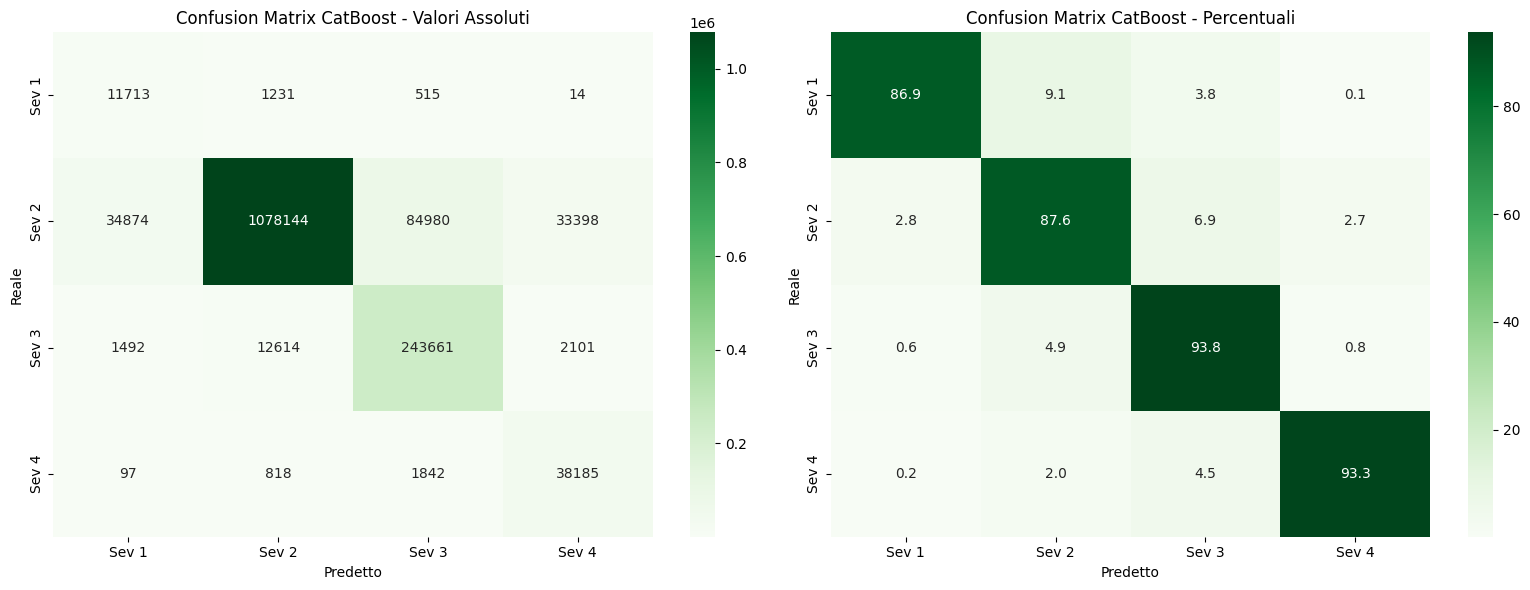

In [9]:
import math

y_pred_cat  = []
batch_size  = 100000

for i in range(0, len(X_test), batch_size):
    batch = X_test.iloc[i:i+batch_size]
    y_pred_cat.append(model_cat.predict(batch).flatten())
    print(f"Batch {i//batch_size + 1}/{math.ceil(len(X_test)/batch_size)} completato")

y_pred_cat = np.concatenate(y_pred_cat)

print("\n" + "="*60)
print("CLASSIFICATION REPORT - CATBOOST - TEST SET")
print("="*60)
print(classification_report(y_test, y_pred_cat,
      target_names=['Severity 1','Severity 2','Severity 3','Severity 4']))

# Confusion Matrix
cm         = confusion_matrix(y_test, y_pred_cat)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Sev 1','Sev 2','Sev 3','Sev 4'],
            yticklabels=['Sev 1','Sev 2','Sev 3','Sev 4'],
            ax=axes[0])
axes[0].set_title('Confusion Matrix CatBoost - Valori Assoluti')
axes[0].set_ylabel('Reale')
axes[0].set_xlabel('Predetto')

sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='Greens',
            xticklabels=['Sev 1','Sev 2','Sev 3','Sev 4'],
            yticklabels=['Sev 1','Sev 2','Sev 3','Sev 4'],
            ax=axes[1])
axes[1].set_title('Confusion Matrix CatBoost - Percentuali')
axes[1].set_ylabel('Reale')
axes[1].set_xlabel('Predetto')

plt.tight_layout()
plt.show()

## MODEL WITH DIFF: WEIGHTS

In [12]:
base_weights          = compute_sample_weight(class_weight='balanced', y=y_train)
sample_weights_custom = base_weights.copy()
mask_class0           = (y_train == 0).values
mask_class2           = (y_train == 2).values
mask_class3           = (y_train == 3).values
sample_weights_custom[mask_class0] *= 0.065
sample_weights_custom[mask_class2] *= 0.45
sample_weights_custom[mask_class3] *= 0.15

for cls in range(4):
    mask = (y_train == cls).values
    print(f"Classe {cls} (Severity {cls+1}): peso medio = {sample_weights_custom[mask].mean():.3f}")

Classe 0 (Severity 1): peso medio = 1.864
Classe 1 (Severity 2): peso medio = 0.314
Classe 2 (Severity 3): peso medio = 0.669
Classe 3 (Severity 4): peso medio = 1.416


## PARAMETERS

In [13]:
ITERATIONS    = 1000
LEARNING_RATE = 0.05
DEPTH         = 15
L2_LEAF_REG   = 0.1
RANDOM_SEED   = 42
PATIENCE      = 100

## MODEL

In [14]:
model_cat_3 = CatBoostClassifier(
    iterations=ITERATIONS,
    learning_rate=LEARNING_RATE,
    depth=DEPTH,
    l2_leaf_reg=L2_LEAF_REG,
    loss_function='MultiClass',
    eval_metric='TotalF1',
    task_type='GPU',
    devices='0',
    random_seed=RANDOM_SEED,
    early_stopping_rounds=PATIENCE,
    metric_period=10,
    verbose=1
)

## TRAIN

In [16]:
model_cat_3.fit(
    X_train, y_train,
    cat_features=cat_features,
    sample_weight=sample_weights_custom,
    eval_set=(X_val, y_val)  
)

0:	learn: 0.8498069	test: 0.8850965	best: 0.8850965 (0)	total: 1.27s	remaining: 21m 11s
10:	learn: 0.8600554	test: 0.8919162	best: 0.8919162 (10)	total: 12.4s	remaining: 18m 39s
20:	learn: 0.8689930	test: 0.8967862	best: 0.8967862 (20)	total: 23.3s	remaining: 18m 7s
30:	learn: 0.8771083	test: 0.9010880	best: 0.9010880 (30)	total: 33.5s	remaining: 17m 25s
40:	learn: 0.8814785	test: 0.9033422	best: 0.9033422 (40)	total: 43.4s	remaining: 16m 54s
50:	learn: 0.8845228	test: 0.9047756	best: 0.9047756 (50)	total: 55.4s	remaining: 17m 11s
60:	learn: 0.8878574	test: 0.9071367	best: 0.9071367 (60)	total: 1m 6s	remaining: 17m 10s
70:	learn: 0.8910655	test: 0.9093459	best: 0.9093459 (70)	total: 1m 18s	remaining: 17m 6s
80:	learn: 0.8931137	test: 0.9107260	best: 0.9107260 (80)	total: 1m 29s	remaining: 16m 53s
90:	learn: 0.8950855	test: 0.9114703	best: 0.9114703 (90)	total: 1m 40s	remaining: 16m 41s
100:	learn: 0.8966430	test: 0.9122195	best: 0.9122195 (100)	total: 1m 51s	remaining: 16m 29s
110:	lea

CatBoostClassifier(depth=15, devices='0', early_stopping_rounds=100, eval_metric='TotalF1', iterations=1000, l2_leaf_reg=0.1, learning_rate=0.05, loss_function='MultiClass', metric_period=10, random_seed=42, task_type='GPU', verbose=1)

## SAVE THE MODEL

In [17]:

import gc
# Salva tutto il necessario


jbl.dump(model_cat_3,  'catboost_model_final_3.pkl')
jbl.dump(km,         'kmeans_geo.pkl')           # per Geo_Cluster su dati nuovi

# Salva le frequenze del frequency encoding
freq_maps = {}
for col in ['City', 'County', 'State', 'Zipcode']:
    if col in X_train.columns:
        freq_maps[col] = X_train[col].value_counts().to_dict()

jbl.dump(freq_maps, 'freq_maps.pkl')

print("Tutto salvato!")
print(f"  - catboost_model_final_3.pkl")
print(f"  - kmeans_geo.pkl")
print(f"  - freq_maps.pkl")

print("Calcolo probabilità CatBoost su val set...")
cat_val_probs = model_cat_3.predict_proba(X_val)
jbl.dump(cat_val_probs, 'cat_val_probs.pkl')
print(f"Val probs salvate! Shape: {cat_val_probs.shape}")

print("\nCalcolo probabilità CatBoost su test set...")
cat_probs = []
for i in range(0, len(X_test), 50000):
    batch = X_test.iloc[i:i+50000]
    cat_probs.append(model_cat_3.predict_proba(batch))
    print(f"CAT Batch {i//50000 + 1}/{math.ceil(len(X_test)/50000)} completato")
    gc.collect()

cat_probs = np.concatenate(cat_probs)
jbl.dump(cat_probs, 'cat_test_probs_1.pkl')
print(f"Test probs salvate! Shape: {cat_probs.shape}")

Tutto salvato!
  - catboost_model_final_3.pkl
  - kmeans_geo.pkl
  - freq_maps.pkl
Calcolo probabilità CatBoost su val set...
Val probs salvate! Shape: (1236543, 4)

Calcolo probabilità CatBoost su test set...
CAT Batch 1/31 completato
CAT Batch 2/31 completato
CAT Batch 3/31 completato
CAT Batch 4/31 completato
CAT Batch 5/31 completato
CAT Batch 6/31 completato
CAT Batch 7/31 completato
CAT Batch 8/31 completato
CAT Batch 9/31 completato
CAT Batch 10/31 completato
CAT Batch 11/31 completato
CAT Batch 12/31 completato
CAT Batch 13/31 completato
CAT Batch 14/31 completato
CAT Batch 15/31 completato
CAT Batch 16/31 completato
CAT Batch 17/31 completato
CAT Batch 18/31 completato
CAT Batch 19/31 completato
CAT Batch 20/31 completato
CAT Batch 21/31 completato
CAT Batch 22/31 completato
CAT Batch 23/31 completato
CAT Batch 24/31 completato
CAT Batch 25/31 completato
CAT Batch 26/31 completato
CAT Batch 27/31 completato
CAT Batch 28/31 completato
CAT Batch 29/31 completato
CAT Batch 30/31 

## EVALUATION

Batch 1/16 completato
Batch 2/16 completato
Batch 3/16 completato
Batch 4/16 completato
Batch 5/16 completato
Batch 6/16 completato
Batch 7/16 completato
Batch 8/16 completato
Batch 9/16 completato
Batch 10/16 completato
Batch 11/16 completato
Batch 12/16 completato
Batch 13/16 completato
Batch 14/16 completato
Batch 15/16 completato
Batch 16/16 completato

CLASSIFICATION REPORT - CATBOOST - TEST SET
              precision    recall  f1-score   support

  Severity 1       0.61      0.64      0.62     13473
  Severity 2       0.97      0.94      0.96   1231396
  Severity 3       0.83      0.90      0.86    259868
  Severity 4       0.62      0.82      0.70     40942

    accuracy                           0.93   1545679
   macro avg       0.76      0.83      0.79   1545679
weighted avg       0.94      0.93      0.93   1545679



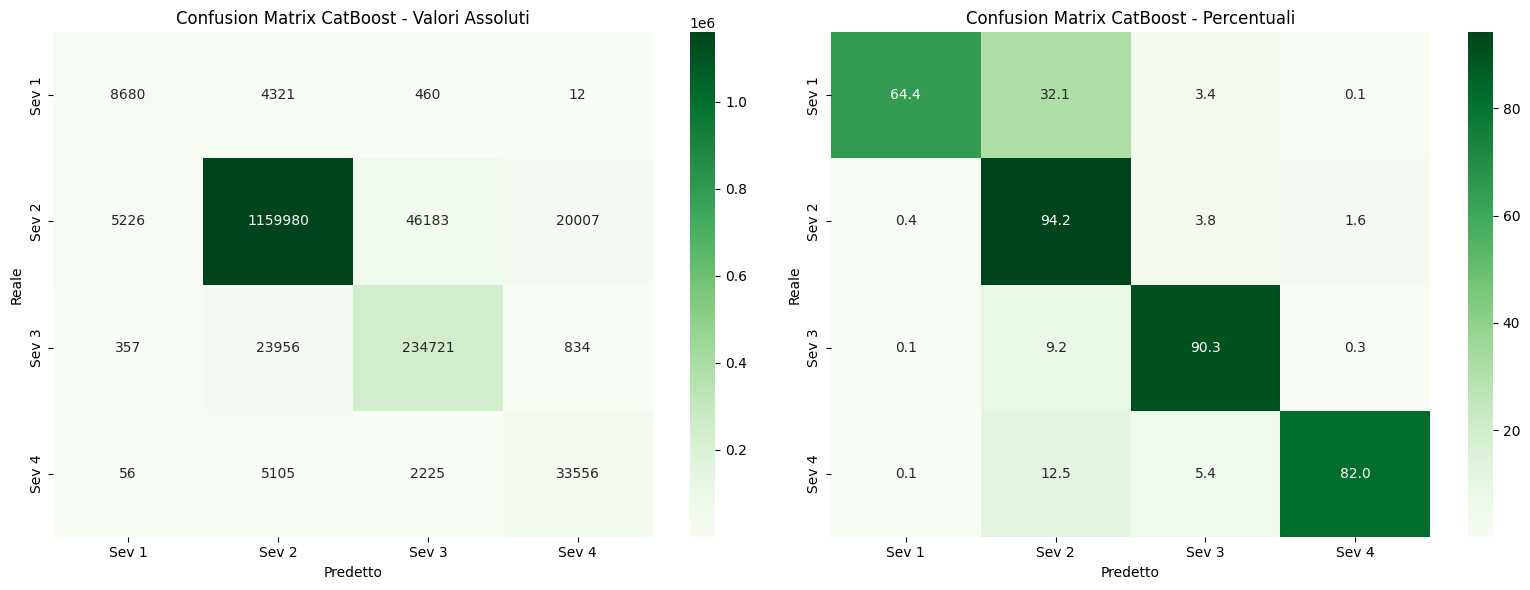

In [18]:
import math

y_pred_cat  = []
batch_size  = 100000

for i in range(0, len(X_test), batch_size):
    batch = X_test.iloc[i:i+batch_size]
    y_pred_cat.append(model_cat_3.predict(batch).flatten())
    print(f"Batch {i//batch_size + 1}/{math.ceil(len(X_test)/batch_size)} completato")

y_pred_cat = np.concatenate(y_pred_cat)

print("\n" + "="*60)
print("CLASSIFICATION REPORT - CATBOOST - TEST SET")
print("="*60)
print(classification_report(y_test, y_pred_cat,
      target_names=['Severity 1','Severity 2','Severity 3','Severity 4']))

# Confusion Matrix
cm         = confusion_matrix(y_test, y_pred_cat)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Sev 1','Sev 2','Sev 3','Sev 4'],
            yticklabels=['Sev 1','Sev 2','Sev 3','Sev 4'],
            ax=axes[0])
axes[0].set_title('Confusion Matrix CatBoost - Valori Assoluti')
axes[0].set_ylabel('Reale')
axes[0].set_xlabel('Predetto')

sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='Greens',
            xticklabels=['Sev 1','Sev 2','Sev 3','Sev 4'],
            yticklabels=['Sev 1','Sev 2','Sev 3','Sev 4'],
            ax=axes[1])
axes[1].set_title('Confusion Matrix CatBoost - Percentuali')
axes[1].set_ylabel('Reale')
axes[1].set_xlabel('Predetto')

plt.tight_layout()
plt.show()


TOP 20 FEATURE IMPORTANCE - CATBOOST
            feature  importance
        Street_Type    6.929842
   duration_min_log    6.019077
    desc_length_log    5.577635
       Pressure(in)    5.541116
          Start_Lng    4.911649
          Start_Lat    4.675991
        time_of_day    4.375645
          month_cos    4.256514
   Distance(mi)_log    4.256028
            Zipcode    4.239169
       desc_highway    4.213430
          month_sin    4.101976
               City    3.766419
Wind_Speed(mph)_log    3.685694
             Source    3.654362
        Humidity(%)    3.641036
             County    3.552793
              State    3.316182
     Temperature(F)    3.141259
      Weather_Group    2.439813


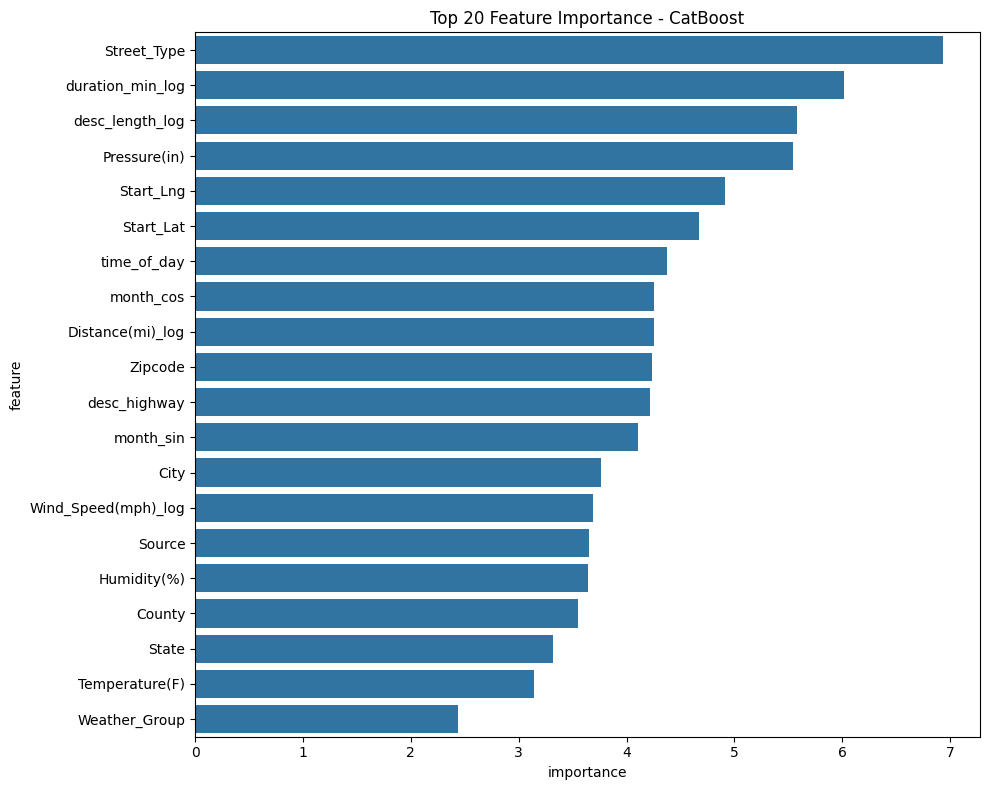

In [11]:
feat_imp_cat = pd.DataFrame({
    'feature':    X_test.columns,
    'importance': model_cat_1.get_feature_importance()
}).sort_values('importance', ascending=False)

print("\n" + "="*60)
print("TOP 20 FEATURE IMPORTANCE - CATBOOST")
print("="*60)
print(feat_imp_cat.head(20).to_string(index=False))

plt.figure(figsize=(10, 8))
sns.barplot(data=feat_imp_cat.head(20), x='importance', y='feature')
plt.title('Top 20 Feature Importance - CatBoost')
plt.tight_layout()
plt.show()